# Generate Synthetic Dataset DS2

This notebook creates the public synthetic DS2 replacement dataset used by the Paper II and Paper III analysis notebooks.

Paper II:
*Øien, Christian Dalheim; Myhr, Ole Runar; Ringen, Geir. Towards hybrid
modelling of aluminium extrusion mechanical properties – A univariate
representation of artificial aging. Materials Research Proceedings 54 (2025),
819–828.
DOI: https://doi.org/10.21741/9781644903599-88*

Paper III:
*Øien, Christian Dalheim; Myhr, Ole Runar; Ringen, Geir. Parallel Hybrid
Modeling of Al–Mg–Si Tensile Properties Using Density-Based Weighting.
Metals 16 (2026), 142.
DOI: https://doi.org/10.3390/met16020142*


The generated data contains:
- 46 synthetic Al–Mg–Si alloy chemistries
- 124 artificial-aging cycles
- 65 selected cycles per alloy
- one row per alloy–cycle combination
- synthetic `Rp0.2` and `Rm` responses
- a Scheil integral representation of artificial aging

The dataset cannot, and is not intended to, match the proprietary D1 dataset numerically. Its purpose is to preserve the relevant structure, variable names, and qualitative trends needed by the analysis notebooks.

## 1. Setup

Define dataset size, output paths, column names, random seed, and the cycle-distribution settings used to make common aging conditions more frequent.

In [1]:
from pathlib import Path
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_SEED = 42
N_ALLOYS = 46
TOTAL_CYCLES = 124
CYCLES_PER_ALLOY = 65

# Cycle-distribution shaping for the Paper III methodology.
# Keep broad Scheil coverage but make a modest fraction of the catalogue
# cluster around a typical T6-like condition close to 185 °C and I ≈ 1.
TYPICAL_CYCLE_FRACTION = 0.22
TYPICAL_TEMP_C = 185
TYPICAL_I_CENTER = 0.83
TYPICAL_LOGI_HALF_WIDTH = 0.42

OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)

DS2_FULL_FILE = OUTPUT_DIR / "DS2_full.xlsx"
DS2_SCHEIL_FILE = OUTPUT_DIR / "DS2_scheil.xlsx"

CHEMISTRY_COLS = [
    "Mg [wt.%]", "Si [wt.%]", "Fe [wt.%]", "Mn [wt.%]", "Cu [wt.%]", "Cr [wt.%]",
]
AGING_SEGMENT_COLS = ["T6", "T7", "T8", "T9", "T10", "t6_7", "t7_8", "t8_9", "t9_10"]
SCHEIL_COL = "Scheil"
TARGET_COLS = ["Rp0.2 [MPa]", "Rm [MPa]"]

DS2_FULL_COLS = CHEMISTRY_COLS + AGING_SEGMENT_COLS + [SCHEIL_COL] + TARGET_COLS
DS2_SCHEIL_COLS = CHEMISTRY_COLS + [SCHEIL_COL] + TARGET_COLS


## 2. Scheil integral

Define the simplified Scheil-integral calculation used to convert each artificial-aging cycle into a single aging-exposure variable.

In [2]:
# Scheil settings used for the synthetic aging-cycle generation.
Q_D = 130_000.0
R_GAS = 8.314
T_REF_K = 185.0 + 273.0
T_REF_SECONDS = 5.0 * 3600.0


def equivalent_isothermal_time_seconds(temp_c):
    temp_k = np.asarray(temp_c, dtype=float) + 273.0
    return T_REF_SECONDS * np.exp((Q_D / R_GAS) * ((1.0 / temp_k) - (1.0 / T_REF_K)))


def scheil_integral_from_row(row, return_profile=False):
    '''
    Compute the Scheil integral from the temperature anchors T6–T10 and the
    corresponding durations t6_7–t9_10.

    The implementation:
    1) places the temperature anchors at their cumulative times,
    2) linearly interpolates the second-resolved temperature profile,
    3) evaluates t* for each second,
    4) accumulates dI = 1 / t*.

    If return_profile=True, the full second-resolved profile is returned as a
    dataframe for inspection.
    '''
    p0 = 0
    p1 = int(row["t6_7"])
    p2 = int(row["t6_7"] + row["t7_8"])
    p3 = int(row["t6_7"] + row["t7_8"] + row["t8_9"] + 1)
    p4 = int(row["t6_7"] + row["t7_8"] + row["t8_9"] + row["t9_10"] + 1)

    anchors = [p0, p1, p2, p3, p4]
    temps_c = [float(row["T6"]), float(row["T7"]), float(row["T8"]), float(row["T9"]), float(row["T10"])]

    pieces = []
    for seg_idx in range(4):
        x0, x1 = anchors[seg_idx], anchors[seg_idx + 1]
        y0, y1 = temps_c[seg_idx], temps_c[seg_idx + 1]
        segment = np.linspace(y0, y1, x1 - x0 + 1)
        if seg_idx > 0:
            segment = segment[1:]
        pieces.append(segment)

    profile_c = np.concatenate(pieces)
    profile_k = profile_c + 273.0
    t_star = T_REF_SECONDS * np.exp((Q_D / R_GAS) * ((1.0 / profile_k) - (1.0 / T_REF_K)))
    d_i = 1.0 / t_star
    i_cum = np.cumsum(d_i)

    if return_profile:
        time_s = np.arange(profile_c.size)
        return pd.DataFrame({
            "time_s": time_s,
            "time_h": time_s / 3600.0,
            "T [C]": profile_c,
            "T [K]": profile_k,
            "t* [s]": t_star,
            "dI": d_i,
            "I": i_cum,
        })

    return float(i_cum[-1])


## 3. Synthetic alloy chemistries

Generate broad Al–Mg–Si chemistry coverage with Mg and Si as the main variables and Fe, Mn, Cu, and Cr as secondary alloying elements.

In [3]:
# -------------------------------------------------------------------------
# Synthetic DS2 chemistry model
#
# DS2 serves a different purpose from DS1.
#
# In DS1, the goal is to provide the broader Paper I modelling methodology that
# uses continuous chemistry variables and categorical aging and alloy variables.
# #
# In DS2, however, we do not use categorical variables. Instead, we use a set
# of continuous physical aging variables as well as a compressed alternative
# in the form of the univariate Scheil integral. Also, the chemistry should be
# broader and formed by 6 concentrations in stead of 14.
#
# The DS2 chemistry model is therefore a bit different:
# - alloys are assigned to a small number of Mg-Si families
# - Mg and Si define the main family-to-family variation
# - Fe, Mn, Cu, and Cr provide secondary alloy-to-alloy variation
# - the ranges are broader
#
# The purpose is to avoid mimicing the original chemistry distribution, i.e. to
# create a transparent set of Al-Mg-Si-like alloys with enough diversity to
# make the synthetic aging-response example meaningful.
# -------------------------------------------------------------------------

# -------------------------------------------------------------------------
# Chemistry-family definitions
#
# Each family defines a broad Mg-Si window. DS2 uses these windows to create
# a controlled progression from leaner to richer Al-Mg-Si-like chemistries.
# The other elements are then added as secondary variation around that family.
# -------------------------------------------------------------------------
CHEMISTRY_FAMILIES = [
    {
        "family_name": "lean",
        "Mg_range": (0.28, 0.48),
        "Si_range": (0.38, 0.62),
    },
    {
        "family_name": "medium",
        "Mg_range": (0.38, 0.58),
        "Si_range": (0.48, 0.74),
    },
    {
        "family_name": "rich",
        "Mg_range": (0.48, 0.72),
        "Si_range": (0.56, 0.86),
    },
    {
        "family_name": "very_rich",
        "Mg_range": (0.58, 0.90),
        "Si_range": (0.66, 0.98),
    },
]


def clipped_normal(rng, mean, std, low, high):
    """Sample from a normal distribution and clip to a bounded interval."""
    return float(np.clip(rng.normal(mean, std), low, high))


def skewed_trace(rng, alpha, beta, scale, offset=0.0, low=0.0, high=1.0):
    """
    Sample a positive-skewed minor element content.

    This is used for elements that are usually present at low levels but may
    occasionally appear in larger amounts.
    """
    value = offset + rng.beta(alpha, beta) * scale
    return float(np.clip(value, low, high))


def sparse_trace(rng, presence_probability, low_when_present, high_when_present, low=0.0, high=1.0):
    """
    Sample a sparse trace element.

    With high probability the element is zero, otherwise a very small positive
    value is assigned.
    """
    if rng.random() > presence_probability:
        return 0.0
    return float(np.clip(rng.uniform(low_when_present, high_when_present), low, high))


def make_synthetic_chemistry(rng, alloy_idx):
    """
    Generate one synthetic DS2 alloy chemistry.

    Logic:
    - pick one of four Mg-Si families in a repeating sequence
    - sample Mg and Si uniformly within that family window
    - add Fe as a narrow background impurity-like variable
    - add Mn and Cu as low-to-moderate positively skewed additions
    - add Cr as a sparse near-zero trace addition

    This keeps the chemistry model simple and readable, which is appropriate
    for DS2 where the aging-cycle representation is the main focus.
    """
    family = CHEMISTRY_FAMILIES[alloy_idx % len(CHEMISTRY_FAMILIES)]

    # Main family-defining elements
    mg = rng.uniform(*family["Mg_range"])
    si = rng.uniform(*family["Si_range"])

    # Secondary variation
    fe = clipped_normal(rng, mean=0.206, std=0.010, low=0.185, high=0.240)
    mn = skewed_trace(rng, alpha=1.2, beta=6.0, scale=0.48, offset=0.014, low=0.010, high=0.500)
    cu = skewed_trace(rng, alpha=0.8, beta=5.0, scale=0.14, offset=0.0, low=0.0, high=0.130)
    cr = sparse_trace(rng, presence_probability=0.15, low_when_present=0.0001, high_when_present=0.0006, low=0.0, high=0.001)

    return {
        "Mg [wt.%]": round(mg, 3),
        "Si [wt.%]": round(si, 3),
        "Fe [wt.%]": round(fe, 3),
        "Mn [wt.%]": round(mn, 3),
        "Cu [wt.%]": round(cu, 3),
        "Cr [wt.%]": round(cr, 3),
    }


## 4. Artificial-aging cycle catalogue

Create a catalogue of synthetic aging cycles spanning underaged to overaged conditions.

The catalogue combines broad Scheil coverage with a modest cluster near `T = 185 °C` and `I ≈ 0.83`, so that typical aging conditions are more frequent than unusual ones.

In [4]:
# -------------------------------------------------------------------------
# Synthetic DS2 cycle-catalog model
#
# The cycle catalogue is built before any alloy rows are created.
#
# The design has three layers:
#
# 1) Target Scheil coverage
#    A set of target I values is defined first. The catalogue should span
#    roughly from underaging (I ~ 1e-2) to overaging (I ~ 1e2).
#
# 2) Cycle families
#    Two simplified cycle families are used:
#
#      type1: one main isothermal hold followed by cooldown
#      type2: two-step cycle with a lower and a higher temperature stage
#
#    These are structured synthetic shapes that produce a broad
#    and interpretable range of Scheil integrals.
#
# 3) Uniqueness and rounding
#    All temperatures are rounded to 5 °C and all durations to 60 s. When two
#    target values would otherwise collapse to the same rounded cycle, a small
#    bounded perturbation is applied to recover a unique catalogue entry.
#
# This means that the catalogue is not generated by random trial-and-error but by
#   target I  ->  select template  ->  solve rounded duration  ->  deduplicate
# -------------------------------------------------------------------------

# -------------------------------------------------------------------------
# Rule tables for mapping target log10(I) to cycle templates
# -------------------------------------------------------------------------

TYPE1_TEMP_RULES = [
    {"logI_max": -1.0, "base_temp": 160},
    {"logI_max": -0.6, "base_temp": 165},
    {"logI_max": -0.1, "base_temp": 170},
    {"logI_max":  0.2, "base_temp": 175},
    {"logI_max":  0.5, "base_temp": 180},
    {"logI_max":  0.8, "base_temp": 185},
    {"logI_max":  1.1, "base_temp": 190},
    {"logI_max":  1.4, "base_temp": 195},
    {"logI_max":  1.7, "base_temp": 200},
    {"logI_max":  1.9, "base_temp": 205},
    {"logI_max": np.inf, "base_temp": 210},
]

TYPE2_TEMPLATE_RULES = [
    {
        "logI_max": -1.0,
        "temp_low_options": [150, 155, 160],
        "temp_high_options": [180, 185, 190],
        "hold_low_options": [60, 120, 300],
        "hold_high_options": [60, 120, 300],
    },
    {
        "logI_max": -0.2,
        "temp_low_options": [150, 155, 160, 165],
        "temp_high_options": [185, 190, 195],
        "hold_low_options": [120, 300, 600],
        "hold_high_options": [120, 300, 600],
    },
    {
        "logI_max": 0.6,
        "temp_low_options": [155, 160, 165, 170],
        "temp_high_options": [190, 195, 200],
        "hold_low_options": [300, 600, 900],
        "hold_high_options": [300, 600, 900],
    },
    {
        "logI_max": np.inf,
        "temp_low_options": [160, 165, 170, 175],
        "temp_high_options": [195, 200, 205, 210],
        "hold_low_options": [600, 900, 1800],
        "hold_high_options": [600, 1800, 3600],
    },
]

TYPE1_TEMP_PERTURBATIONS = [0, 5, -5, 10, -10]
TYPE2_TEMP_PERTURBATIONS = [0, 5, -5, 10]
TYPE2_HOLD_PERTURBATIONS = [0, -60, 60]

def make_type1_cycle(temp_c, hold_seconds, ramp_seconds=7200, settle_seconds=60, final_seconds=60):
    return {
        "cycle_type": "type1",
        "T6": 20,
        "T7": int(temp_c),
        "T8": int(temp_c),
        "T9": 20,
        "T10": 20,
        "t6_7": int(ramp_seconds),
        "t7_8": int(hold_seconds),
        "t8_9": int(settle_seconds),
        "t9_10": int(final_seconds),
    }


def make_type2_cycle(temp_low_c, temp_high_c, hold_low_seconds, ramp_mid_seconds, hold_high_seconds, ramp_in_seconds=600):
    return {
        "cycle_type": "type2",
        "T6": 20,
        "T7": int(temp_low_c),
        "T8": int(temp_low_c),
        "T9": int(temp_high_c),
        "T10": int(temp_high_c),
        "t6_7": int(ramp_in_seconds),
        "t7_8": int(hold_low_seconds),
        "t8_9": int(ramp_mid_seconds),
        "t9_10": int(hold_high_seconds),
    }


def cycle_key(row):
    return tuple(int(row[col]) for col in AGING_SEGMENT_COLS)


def type1_base_temp_from_logI(target_log_i):
    """Map target log10(I) to a base temperature for a type1 cycle."""
    for rule in TYPE1_TEMP_RULES:
        if target_log_i <= rule["logI_max"]:
            return rule["base_temp"]
    raise RuntimeError("No type1 temperature rule matched.")


def type2_template_from_logI(target_log_i):
    """Map target log10(I) to a type2 template family."""
    for rule in TYPE2_TEMPLATE_RULES:
        if target_log_i <= rule["logI_max"]:
            return rule
    raise RuntimeError("No type2 template rule matched.")


def choose_type1_temp(target_log_i, idx):
    """
    Choose a type1 temperature.

    A base temperature is first selected from the rule table. In the middle
    part of the Scheil range, a small ±5 °C variation is introduced to avoid
    over-concentrating the catalogue on a single temperature.
    """
    base_temp = type1_base_temp_from_logI(target_log_i)
    if -0.2 <= target_log_i <= 1.6:
        base_temp = int(np.clip(base_temp + [-5, 0, 5][idx % 3], 150, 210))
    return base_temp


def choose_type2_params(target_log_i, idx):
    """
    Choose a type2 template from the rule table.

    The options are deliberately small and rounded. The index-dependent
    selection simply spreads the catalogue across the available template
    combinations.
    """
    template = type2_template_from_logI(target_log_i)
    lows = template["temp_low_options"]
    highs = template["temp_high_options"]
    hold_lows = template["hold_low_options"]
    hold_highs = template["hold_high_options"]

    return (
        lows[idx % len(lows)],
        highs[(idx // 2) % len(highs)],
        hold_lows[idx % len(hold_lows)],
        hold_highs[(idx // 3) % len(hold_highs)],
    )


def solve_type1_cycle(target_i, temp_c, max_hold_seconds=120 * 3600):
    lo, hi = 60, int(max_hold_seconds)

    def eval_hold(hold_seconds):
        cycle = make_type1_cycle(temp_c=temp_c, hold_seconds=hold_seconds)
        return scheil_integral_from_row(cycle)

    if target_i <= eval_hold(lo):
        hold = lo
    elif target_i >= eval_hold(hi):
        hold = hi
    else:
        while hi - lo > 60:
            mid = int(((lo + hi) // 120) * 60)
            mid = max(lo + 60, mid)
            if eval_hold(mid) < target_i:
                lo = mid
            else:
                hi = mid
        candidate_holds = range(max(60, lo - 300), min(int(max_hold_seconds), hi + 300) + 1, 60)
        hold = min(candidate_holds, key=lambda h: abs(eval_hold(h) - target_i))

    cycle = make_type1_cycle(temp_c=temp_c, hold_seconds=int(hold))
    cycle["Scheil"] = scheil_integral_from_row(cycle)
    return cycle


def solve_type2_cycle(target_i, temp_low_c, temp_high_c, hold_low_seconds, hold_high_seconds, max_ramp_mid_seconds=96 * 3600):
    lo, hi = 60, int(max_ramp_mid_seconds)

    def eval_ramp(ramp_mid_seconds):
        cycle = make_type2_cycle(
            temp_low_c=temp_low_c,
            temp_high_c=temp_high_c,
            hold_low_seconds=hold_low_seconds,
            ramp_mid_seconds=ramp_mid_seconds,
            hold_high_seconds=hold_high_seconds,
        )
        return scheil_integral_from_row(cycle)

    if target_i <= eval_ramp(lo):
        ramp_mid = lo
    elif target_i >= eval_ramp(hi):
        ramp_mid = hi
    else:
        while hi - lo > 60:
            mid = int(((lo + hi) // 120) * 60)
            mid = max(lo + 60, mid)
            if eval_ramp(mid) < target_i:
                lo = mid
            else:
                hi = mid
        candidate_ramps = range(max(60, lo - 300), min(int(max_ramp_mid_seconds), hi + 300) + 1, 60)
        ramp_mid = min(candidate_ramps, key=lambda r: abs(eval_ramp(r) - target_i))

    cycle = make_type2_cycle(
        temp_low_c=temp_low_c,
        temp_high_c=temp_high_c,
        hold_low_seconds=hold_low_seconds,
        ramp_mid_seconds=int(ramp_mid),
        hold_high_seconds=hold_high_seconds,
    )
    cycle["Scheil"] = scheil_integral_from_row(cycle)
    return cycle

def iter_type1_candidates(target_i, target_log_i, idx):
    """
    Generate a small ordered list of candidate type1 cycles for one target I.

    The first candidate is the nominal cycle. Later candidates are small
    bounded temperature perturbations used only if the nominal cycle would
    duplicate an existing rounded catalogue entry.
    """
    base_temp = choose_type1_temp(target_log_i, idx)
    for d_temp in TYPE1_TEMP_PERTURBATIONS:
        temp = base_temp + d_temp
        if 150 <= temp <= 210:
            yield solve_type1_cycle(target_i=target_i, temp_c=temp)


def iter_type2_candidates(target_i, target_log_i, idx):
    """
    Generate a small ordered list of candidate type2 cycles for one target I.

    The nominal template is tried first. If that rounded cycle is already
    present in the catalogue, small bounded perturbations in temperature and
    hold durations are explored.
    """
    temp_low_c, temp_high_c, hold_low_seconds, hold_high_seconds = choose_type2_params(target_log_i, idx)

    for low_shift in TYPE2_TEMP_PERTURBATIONS:
        for high_shift in TYPE2_TEMP_PERTURBATIONS:
            low = temp_low_c + low_shift
            high = temp_high_c + high_shift
            if not (150 <= low < high <= 210):
                continue

            for d_hold_low in TYPE2_HOLD_PERTURBATIONS:
                for d_hold_high in TYPE2_HOLD_PERTURBATIONS:
                    hold_low = max(60, hold_low_seconds + d_hold_low)
                    hold_high = max(60, hold_high_seconds + d_hold_high)

                    yield solve_type2_cycle(
                        target_i=target_i,
                        temp_low_c=low,
                        temp_high_c=high,
                        hold_low_seconds=hold_low,
                        hold_high_seconds=hold_high,
                    )

def clustered_log_targets(n, center=np.log10(TYPICAL_I_CENTER), half_width=TYPICAL_LOGI_HALF_WIDTH):
    """
    Generate deterministic log10(I) targets clustered around a center value.

    The transformation compresses more target values toward the center while
    still giving some spread. This creates a realistic concentration of aging
    cycles around a common condition without making all typical cycles identical.
    """
    if n <= 0:
        return np.array([])

    x = np.linspace(-1.0, 1.0, n)

    # Exponent > 1 compresses values toward the center.
    return center + half_width * np.sign(x) * np.abs(x) ** 1.7


def iter_typical_type1_candidates(target_i, idx):
    """
    Generate candidate typical cycles around T = 185 °C.

    The nominal candidate is exactly 185 °C. Small temperature perturbations
    are only used as fallbacks if a rounded cycle duplicates an existing one.
    """
    for d_temp in [0, -5, 5, -10, 10]:
        temp = TYPICAL_TEMP_C + d_temp
        if 165 <= temp <= 210:
            cycle = solve_type1_cycle(target_i=target_i, temp_c=temp)
            cycle["cycle_type"] = "typical_185"
            yield cycle

def first_unique_cycle(candidates, seen):
    """
    Return the first candidate cycle whose rounded aging path is not already
    present in the catalogue. If all candidates are duplicates, return the
    first one anyway.
    """
    fallback = None
    for cycle in candidates:
        if fallback is None:
            fallback = cycle
        key = cycle_key(cycle)
        if key not in seen:
            return cycle
    return fallback


def build_cycle_catalog(total_cycles=TOTAL_CYCLES):
    """
    Build the synthetic cycle catalogue first, before assigning cycles to alloys.

    The catalogue has two components:

    1) Broad coverage:
       type1 and type2 cycles spanning underaged to overaged conditions.

    2) Typical-aging cluster:
       additional type1 cycles concentrated around T = 185 °C and I ≈ 0.83–1.0.

    This preserves the broad Scheil range while making the frequency of
    (T, I) conditions less flat. The effect is important for the Paper III
    coefficient-field analysis: T = 185 °C, I = 0.83 should be more typical
    than T = 170 °C, I = 0.10.
    """
    n_typical = int(round(total_cycles * TYPICAL_CYCLE_FRACTION))
    n_broad = total_cycles - n_typical

    n_type1 = n_broad // 2
    n_type2 = n_broad - n_type1

    # Broad component: retains underaged -> overaged coverage.
    type1_targets = np.logspace(-2, 2, n_type1)

    # Type2 remains capped below the most severe I values.
    type2_targets = np.logspace(-2, np.log10(30.0), n_type2)

    # Typical component: clustered around I ≈ 0.83 at T ≈ 185 °C.
    typical_log_targets = clustered_log_targets(
        n_typical,
        center=np.log10(TYPICAL_I_CENTER),
        half_width=TYPICAL_LOGI_HALF_WIDTH,
    )
    typical_targets = 10 ** typical_log_targets

    cycles = []
    seen = set()

    # Broad type1 cycles.
    for idx, target_i in enumerate(type1_targets):
        target_log_i = np.log10(target_i)
        cycle = first_unique_cycle(
            iter_type1_candidates(target_i, target_log_i, idx),
            seen,
        )
        seen.add(cycle_key(cycle))
        cycles.append(cycle)

    # Broad type2 cycles.
    for idx, target_i in enumerate(type2_targets):
        target_log_i = np.log10(target_i)
        cycle = first_unique_cycle(
            iter_type2_candidates(target_i, target_log_i, idx),
            seen,
        )
        seen.add(cycle_key(cycle))
        cycles.append(cycle)

    # Typical T = 185 °C cycles.
    for idx, target_i in enumerate(typical_targets):
        cycle = first_unique_cycle(
            iter_typical_type1_candidates(target_i, idx),
            seen,
        )
        seen.add(cycle_key(cycle))
        cycles.append(cycle)

    cycles_df = pd.DataFrame(cycles).drop_duplicates(subset=AGING_SEGMENT_COLS).copy()
    cycles_df["Scheil"] = cycles_df.apply(scheil_integral_from_row, axis=1)
    cycles_df["log10_I"] = np.log10(cycles_df["Scheil"])

    # This is the temperature used by the Paper III analysis notebook when
    # reconstructing Ageing_holding_temperature.
    cycles_df["Ageing_holding_temperature"] = cycles_df[["T7", "T9"]].max(axis=1)

    cycles_df = cycles_df.sort_values("log10_I").reset_index(drop=True)
    cycles_df.index = pd.Index(range(1, len(cycles_df) + 1), name="cycle_id")

    return cycles_df


def select_cycle_indices_for_alloy(cycles_df, cycles_per_alloy, rng):
    '''
    Select cycles per alloy with broad coverage across the sorted Scheil range.
    '''
    n_cycles = len(cycles_df)
    base_positions = np.linspace(0, n_cycles - 1, cycles_per_alloy)
    jitter = rng.integers(-1, 2, size=cycles_per_alloy)
    jitter[0] = 0
    jitter[-1] = 0
    proposed = np.clip(np.round(base_positions).astype(int) + jitter, 0, n_cycles - 1)

    selected = []
    used = set()
    for pos, cycle_idx in enumerate(proposed):
        if pos > 0:
            cycle_idx = max(cycle_idx, selected[-1] + 1)
        while cycle_idx in used and cycle_idx < n_cycles:
            cycle_idx += 1
        if cycle_idx >= n_cycles:
            cycle_idx = n_cycles - 1
            while cycle_idx in used and cycle_idx >= 0:
                cycle_idx -= 1
        selected.append(cycle_idx)
        used.add(cycle_idx)

    if len(used) < cycles_per_alloy:
        missing = [i for i in range(n_cycles) if i not in used]
        n_missing = cycles_per_alloy - len(used)
        extra_positions = np.linspace(0, len(missing) - 1, n_missing).round().astype(int)
        selected.extend(missing[pos] for pos in extra_positions)

    return sorted(selected[:cycles_per_alloy])


## 5. Synthetic tensile-property model

Generate deterministic synthetic `Rp0.2` and `Rm` values from chemistry and aging exposure.

The response model is designed to give lean 6060-like chemistries lower strength than richer non-6060 chemistries, while preserving smooth continuous trends.

In [5]:
# -------------------------------------------------------------------------
# Synthetic DS2 response model
#
# The response model is still intentionally simple and synthetic, but it now
# gives chemistry a stronger and more realistic role:
#
# - Mg and Si control the precipitation-hardening potential.
# - Lean low-Mg/low-Si alloys have a lower attainable strength level.
# - The Scheil integral controls the underaged -> peak-aged -> overaged response.
# - Secondary elements add smaller alloy-to-alloy variation.
#
# This is important for the Paper III methodology because the numerical
# experiment introduces the 6060 regime late in the training sequence. The
# 6060 subset should therefore be both geometrically distinct in Mg-Si space
# and visibly lower in Rp0.2 than the richer non-6060 compositions.
#
# The model is not intended as a mechanistic strength model. It is a public,
# deterministic synthetic target generator with qualitatively realistic trends.
# -------------------------------------------------------------------------

def synthetic_strength(row, rng):
    mg = row["Mg [wt.%]"]
    si = row["Si [wt.%]"]
    fe = row["Fe [wt.%]"]
    mn = row["Mn [wt.%]"]
    cu = row["Cu [wt.%]"]
    cr = row["Cr [wt.%]"]
    log_i = np.log10(max(row["Scheil"], 1e-6))

    # ---------------------------------------------------------------------
    # Chemistry terms
    # ---------------------------------------------------------------------
    # Approximate Mg2Si-related precipitation potential.
    # The factor 1.73 is the approximate Mg/Si mass ratio in Mg2Si.
    # This is used only as a compact synthetic proxy for hardening solute.
    mg_si_ratio = mg / max(si, 1e-6)
    balance = np.exp(-0.5 * ((mg_si_ratio - 1.05) / 0.55) ** 2)

    mg2si_potential = min(mg, 1.73 * si)
    excess_si = max(si - mg / 1.73, 0.0)
    total_solute = mg + si

    # Compared with the previous version, this term is less aggressively
    # saturated and therefore preserves a clearer low-solute vs high-solute
    # strength difference.
    solute_term = (
        80.0
        + 155.0 * (1.0 - np.exp(-1.35 * mg2si_potential))
        + 20.0 * excess_si
        + 10.0 * balance
    )

    # Smooth chemistry-level shift: low Mg+Si alloys are weaker, richer alloys
    # are stronger. This avoids a hard artificial step at the 6060 boundary.
    chemistry_term = 40.0 * np.tanh((total_solute - 1.15) / 0.32)

    # Additional soft penalty for very lean chemistries. This helps the 6060
    # region behave as the lower-strength regime seen in the paper figure,
    # while still being continuous in chemistry.
    low_solute_penalty = -18.0 * np.clip((0.95 - total_solute) / 0.35, 0.0, 1.0)
    very_lean_mg_penalty = -10.0 * np.clip((0.40 - mg) / 0.16, 0.0, 1.0)

    # Smaller secondary-element contribution. These terms add realistic
    # alloy-to-alloy variation without dominating the Mg-Si effect.
    secondary_term = (
        8.0 * mn
        + 18.0 * cu
        + 4.0 * cr
        - 10.0 * fe
    )

    # ---------------------------------------------------------------------
    # Aging response
    # ---------------------------------------------------------------------
    # Broad asymmetric peak around I = 1. The right side is wider to avoid
    # making over-aging unrealistically abrupt in the synthetic dataset.
    center = 0.0
    asym = 0.5 * (mg - si) + 0.06 * (balance - 0.5)
    left_scale = 0.85 + 0.08 * balance - 0.05 * asym
    right_scale = 1.10 + 0.60 * balance + 0.05 * asym

    x = np.where(
        log_i < center,
        (center - log_i) / left_scale,
        (log_i - center) / right_scale,
    )

    age_response = 0.6 + 0.4 / (1.0 + x**1.35)

    # Extra penalty for strongly underaged cycles.
    under_aged_penalty = -30.0 * max(-1.10 - log_i, 0.0)

    # ---------------------------------------------------------------------
    # Final synthetic tensile properties
    # ---------------------------------------------------------------------
    rp02 = (
        75.0
        + solute_term * age_response
        + chemistry_term
        + low_solute_penalty
        + very_lean_mg_penalty
        + secondary_term
        + under_aged_penalty
    )

    rp02 += rng.normal(0.0, 7.0)

    rm = (
        rp02
        + 42.0
        + 15.0 * age_response
        + 8.0 * (mg + si)
        + rng.normal(0.0, 5.0)
    )

    rp02 = float(np.clip(rp02, 60.0, 360.0))
    rm = float(np.clip(max(rm, rp02 + 8.0), 110.0, 410.0))

    return round(rp02, 1), round(rm, 1)

## 6. Build and export DS2

Combine alloy chemistries and selected aging cycles, compute the Scheil integral and synthetic tensile properties, then export the full and Scheil-reduced DS2 files.

In [6]:
def build_ds2_full(n_alloys=N_ALLOYS, total_cycles=TOTAL_CYCLES, cycles_per_alloy=CYCLES_PER_ALLOY, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)

    alloys = [make_synthetic_chemistry(rng, alloy_idx) for alloy_idx in range(n_alloys)]
    alloys_df = pd.DataFrame(alloys)
    alloys_df.index = pd.Index(range(1, len(alloys_df) + 1), name="alloy_id")

    cycles_df = build_cycle_catalog(total_cycles=total_cycles)
    rows = []

    for alloy_id, chemistry in alloys_df.iterrows():
        selected_positions = select_cycle_indices_for_alloy(cycles_df, cycles_per_alloy, rng)
        selected_cycles = cycles_df.iloc[selected_positions]

        for _, cycle in selected_cycles.iterrows():
            row = chemistry.to_dict()
            for col in AGING_SEGMENT_COLS:
                row[col] = int(cycle[col])
            row["Scheil"] = float(cycle["Scheil"])
            row["Rp0.2 [MPa]"], row["Rm [MPa]"] = synthetic_strength(row, rng)
            rows.append(row)

    ds2_full = pd.DataFrame(rows, columns=DS2_FULL_COLS)
    ds2_full.index = pd.Index(range(1, len(ds2_full) + 1), name="id")
    ds2_scheil = ds2_full.drop(columns=AGING_SEGMENT_COLS)[DS2_SCHEIL_COLS]

    return ds2_full, ds2_scheil, alloys_df, cycles_df


ds2_full, ds2_scheil, alloys_df, cycles_df = build_ds2_full()

ds2_full.to_excel(DS2_FULL_FILE, index=True)
ds2_scheil.to_excel(DS2_SCHEIL_FILE, index=True)

print("Alloys:", alloys_df.shape)
print("Cycle catalogue:", cycles_df.shape)
print("DS2_full:", ds2_full.shape)
print("DS2_scheil:", ds2_scheil.shape)
print(f"Wrote {DS2_FULL_FILE}")
print(f"Wrote {DS2_SCHEIL_FILE}")


Alloys: (46, 6)
Cycle catalogue: (124, 13)
DS2_full: (2990, 18)
DS2_scheil: (2990, 9)
Wrote data\DS2_full.xlsx
Wrote data\DS2_scheil.xlsx


## 7. Chemistry–strength diagnostic

Check that the generated 6060-like regime is visibly lower in `Rp0.2` than the non-6060 regime.

This is important for the Paper III methodology, where 6060 rows are introduced late in the training sequence.

In [7]:
# Diagnostic check for the Paper III methodology:
# the 6060 regime should be visibly lower in Rp0.2 than the non-6060 regime.
ds2_diagnostic = ds2_full.copy()
ds2_diagnostic["alloy_type"] = np.where(
    (ds2_diagnostic["Mg [wt.%]"] < 0.6) & (ds2_diagnostic["Si [wt.%]"] < 0.6),
    "6060",
    "non-6060",
)

strength_summary = (
    ds2_diagnostic
    .groupby("alloy_type")
    .agg(
        n=("Rp0.2 [MPa]", "size"),
        mg_mean=("Mg [wt.%]", "mean"),
        si_mean=("Si [wt.%]", "mean"),
        rp02_mean=("Rp0.2 [MPa]", "mean"),
        rp02_std=("Rp0.2 [MPa]", "std"),
        rp02_min=("Rp0.2 [MPa]", "min"),
        rp02_max=("Rp0.2 [MPa]", "max"),
        rm_mean=("Rm [MPa]", "mean"),
    )
    .round(1)
)

display(strength_summary)

rp02_gap = (
    strength_summary.loc["non-6060", "rp02_mean"]
    - strength_summary.loc["6060", "rp02_mean"]
)

,n,mg_mean,si_mean,rp02_mean,rp02_std,rp02_min,rp02_max,rm_mean
alloy_type,,,,,,,,
6060,1235,0.4,0.5,180.6,28.5,88.1,247.8,243.1
non-6060,1755,0.6,0.8,250.8,32.6,148.2,328.8,316.7


## 8. Dataset summary

Inspect the generated dataset size, Scheil range, cycle catalogue, and exported DS2 table.

In [8]:
generation_summary = pd.DataFrame({
    "metric": [
        "number of alloys",
        "number of catalogue cycles",
        "cycles per alloy",
        "number of generated rows",
        "Scheil min (catalogue)",
        "Scheil max (catalogue)",
        "Scheil min (rows)",
        "Scheil max (rows)",
    ],
    "value": [
        len(alloys_df),
        len(cycles_df),
        CYCLES_PER_ALLOY,
        len(ds2_full),
        float(cycles_df["Scheil"].min()),
        float(cycles_df["Scheil"].max()),
        float(ds2_full["Scheil"].min()),
        float(ds2_full["Scheil"].max()),
    ],
})

display(generation_summary)
display(cycles_df)
display(ds2_full)


,metric,value
0,number of alloys,46.000000
1,number of catalogue cycles,124.000000
2,cycles per alloy,65.000000
3,number of generated rows,2990.000000
4,Scheil min (catalogue),0.009686
5,Scheil max (catalogue),100.002463
6,Scheil min (rows),0.009686
7,Scheil max (rows),100.002463


,cycle_type,T6,T7,T8,T9,T10,t6_7,t7_8,t8_9,t9_10,Scheil,log10_I,Ageing_holding_temperature
cycle_id,,,,,,,,,,,,,
1,type2,20,150,150,180,180,600,60,480,60,0.009686,-2.013857,180
2,type1,20,160,160,20,20,7200,720,60,60,0.010138,-1.994047,160
3,type1,20,160,160,20,20,7200,960,60,60,0.011995,-1.920989,160
4,type2,20,155,155,180,180,600,120,540,60,0.012190,-1.913987,180
5,type2,20,160,160,185,185,600,300,300,60,0.013489,-1.870015,185
...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,type1,20,200,200,20,20,7200,277860,60,60,45.667195,1.659604,200
121,type1,20,205,205,20,20,7200,239100,60,60,55.547460,1.744664,205
122,type1,20,205,205,20,20,7200,291000,60,60,67.577577,1.829803,205


,Mg [wt.%],Si [wt.%],Fe [wt.%],Mn [wt.%],Cu [wt.%],Cr [wt.%],T6,T7,T8,T9,T10,t6_7,t7_8,t8_9,t9_10,Scheil,Rp0.2 [MPa],Rm [MPa]
id,,,,,,,,,,,,,,,,,,
1,0.435,0.485,0.214,0.206,0.042,0.0,20,150,150,180,180,600,60,480,60,0.009686,141.5,211.4
2,0.435,0.485,0.214,0.206,0.042,0.0,20,155,155,180,180,600,120,540,60,0.012190,132.1,187.9
3,0.435,0.485,0.214,0.206,0.042,0.0,20,160,160,185,185,600,300,300,60,0.013489,143.7,211.8
4,0.435,0.485,0.214,0.206,0.042,0.0,20,150,150,185,185,600,60,480,120,0.016255,136.8,198.1
5,0.435,0.485,0.214,0.206,0.042,0.0,20,155,155,190,190,600,120,300,120,0.019008,160.8,212.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2986,0.549,0.646,0.204,0.060,0.013,0.0,20,170,170,210,210,600,900,194820,600,21.491934,222.6,296.8
2987,0.549,0.646,0.204,0.060,0.013,0.0,20,205,205,20,20,7200,132600,60,60,30.861384,214.3,280.2
2988,0.549,0.646,0.204,0.060,0.013,0.0,20,200,200,20,20,7200,277860,60,60,45.667195,222.7,287.9


## 9. Mg–Si and strength distribution

Plot the synthetic Mg–Si coverage and the resulting `Rp0.2` separation between 6060 and non-6060 rows.

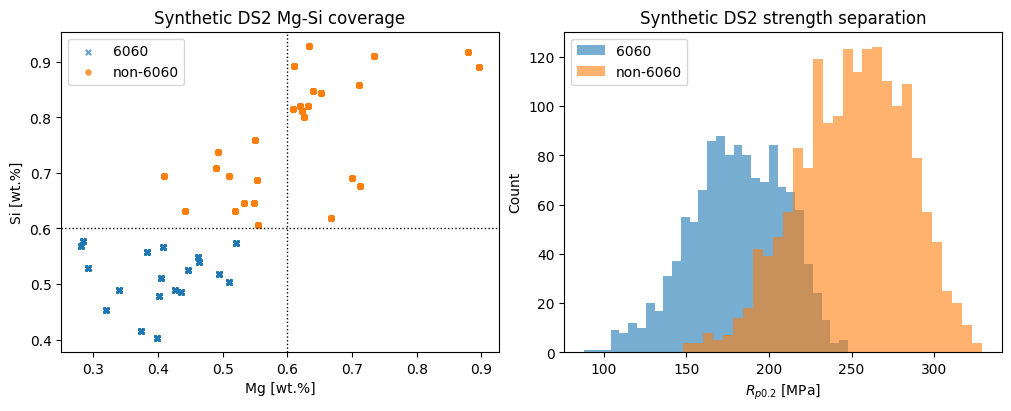

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

plot_df = ds2_full.copy()
plot_df["alloy_type"] = np.where(
    (plot_df["Mg [wt.%]"] < 0.6) & (plot_df["Si [wt.%]"] < 0.6),
    "6060",
    "non-6060",
)

for alloy_type, marker, color in [
    ("6060", "x", "tab:blue"),
    ("non-6060", "o", "tab:orange"),
]:
    tmp = plot_df[plot_df["alloy_type"] == alloy_type]
    axes[0].scatter(
        tmp["Mg [wt.%]"],
        tmp["Si [wt.%]"],
        s=14,
        alpha=0.7,
        marker=marker,
        label=alloy_type,
        color=color,
    )

axes[0].axvline(0.6, color="k", linestyle=":", linewidth=1)
axes[0].axhline(0.6, color="k", linestyle=":", linewidth=1)
axes[0].set_xlabel("Mg [wt.%]")
axes[0].set_ylabel("Si [wt.%]")
axes[0].set_title("Synthetic DS2 Mg-Si coverage")
axes[0].legend(frameon=True)

for alloy_type, color in [
    ("6060", "tab:blue"),
    ("non-6060", "tab:orange"),
]:
    tmp = plot_df[plot_df["alloy_type"] == alloy_type]
    axes[1].hist(
        tmp["Rp0.2 [MPa]"],
        bins=30,
        alpha=0.6,
        label=alloy_type,
        color=color,
    )

axes[1].set_xlabel("$R_{p0.2}$ [MPa]")
axes[1].set_ylabel("Count")
axes[1].set_title("Synthetic DS2 strength separation")
axes[1].legend(frameon=True)

plt.show()

## 10. Aging-condition frequency diagnostic

Quantify how often the generated cycles occur near the two coefficient-field slices used in the Paper III methodology:

- `T = 170 °C`, `I = 0.10`
- `T = 185 °C`, `I = 0.83`

In [10]:
cycle_diag = cycles_df.copy()
cycle_diag["Ageing_holding_temperature"] = cycle_diag[["T7", "T9"]].max(axis=1)

row_diag = ds2_full.copy()
row_diag["Ageing_holding_temperature"] = row_diag[["T7", "T9"]].max(axis=1)

def summarize_t_i_distribution(df, label):
    t = df["Ageing_holding_temperature"]
    i = df["Scheil"]

    near_upper_slice = t.between(165, 175) & i.between(0.07, 0.15)
    near_lower_slice = t.between(180, 190) & i.between(0.50, 1.20)
    near_peak = i.between(0.50, 1.50)

    return {
        "dataset": label,
        "n": len(df),
        "near T=170, I=0.10": int(near_upper_slice.sum()),
        "near T=185, I=0.83": int(near_lower_slice.sum()),
        "near I=1": int(near_peak.sum()),
        "share near T=185, I=0.83": float(near_lower_slice.mean()),
        "share near T=170, I=0.10": float(near_upper_slice.mean()),
    }

t_i_summary = pd.DataFrame([
    summarize_t_i_distribution(cycle_diag, "cycle catalogue"),
    summarize_t_i_distribution(row_diag, "generated rows"),
])

display(t_i_summary)

,dataset,n,"near T=170, I=0.10","near T=185, I=0.83",near I=1,"share near T=185, I=0.83","share near T=170, I=0.10"
0,cycle catalogue,124,2,19,31,0.153226,0.016129
1,generated rows,2990,44,483,740,0.161538,0.014716


## 11. Aging-condition distribution

Visualize the cycle catalogue and generated row density in `(T, I)` space.

The intended behavior is broad Scheil coverage with a higher density near the typical `T = 185 °C`, `I ≈ 0.83` condition.

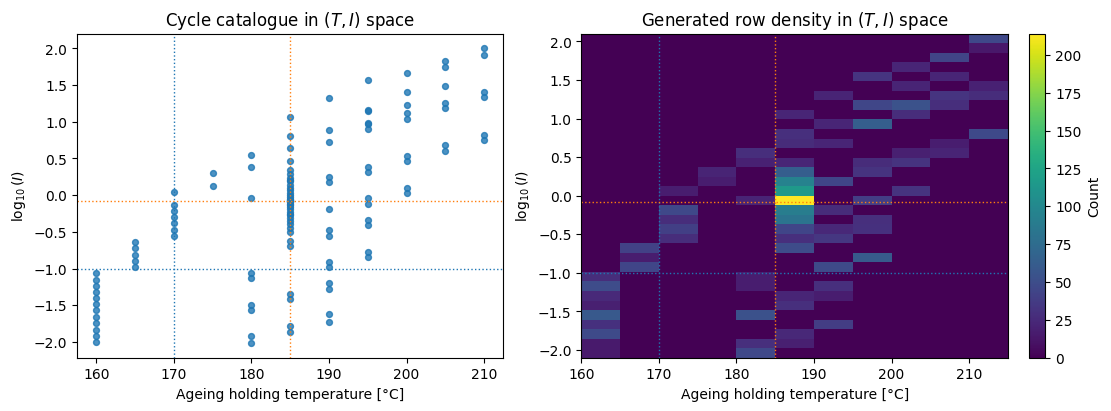

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

plot_cycles = cycles_df.copy()
plot_cycles["Ageing_holding_temperature"] = plot_cycles[["T7", "T9"]].max(axis=1)

plot_rows = ds2_full.copy()
plot_rows["Ageing_holding_temperature"] = plot_rows[["T7", "T9"]].max(axis=1)
plot_rows["log10_I"] = np.log10(plot_rows["Scheil"])

# Catalogue-level scatter.
axes[0].scatter(
    plot_cycles["Ageing_holding_temperature"],
    np.log10(plot_cycles["Scheil"]),
    s=18,
    alpha=0.8,
)
axes[0].axvline(170, color="tab:blue", linestyle=":", linewidth=1)
axes[0].axhline(np.log10(0.10), color="tab:blue", linestyle=":", linewidth=1)
axes[0].axvline(185, color="tab:orange", linestyle=":", linewidth=1)
axes[0].axhline(np.log10(0.83), color="tab:orange", linestyle=":", linewidth=1)
axes[0].set_xlabel("Ageing holding temperature [°C]")
axes[0].set_ylabel(r"$\log_{10}(I)$")
axes[0].set_title("Cycle catalogue in $(T, I)$ space")

# Row-level density.
h = axes[1].hist2d(
    plot_rows["Ageing_holding_temperature"],
    plot_rows["log10_I"],
    bins=[np.arange(160, 216, 5), np.linspace(-2.1, 2.1, 35)],
)
axes[1].axvline(170, color="tab:blue", linestyle=":", linewidth=1)
axes[1].axhline(np.log10(0.10), color="tab:blue", linestyle=":", linewidth=1)
axes[1].axvline(185, color="tab:orange", linestyle=":", linewidth=1)
axes[1].axhline(np.log10(0.83), color="tab:orange", linestyle=":", linewidth=1)
axes[1].set_xlabel("Ageing holding temperature [°C]")
axes[1].set_ylabel(r"$\log_{10}(I)$")
axes[1].set_title("Generated row density in $(T, I)$ space")
fig.colorbar(h[3], ax=axes[1], label="Count")

plt.show()